In [1]:
import os
import sys
import glob
import awkward as ak
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
from torch.utils.data import ConcatDataset
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool
from torch_geometric.nn import GCNConv as gcn
from torch_geometric.nn import EdgeConv 
from torch_geometric.nn import DynamicEdgeConv 
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [2]:
#load in our inference file:
inference_file = np.load("/standard/ldmxuva/gnn_files/note_stuff/run_output/gnn_results.npz")

293500


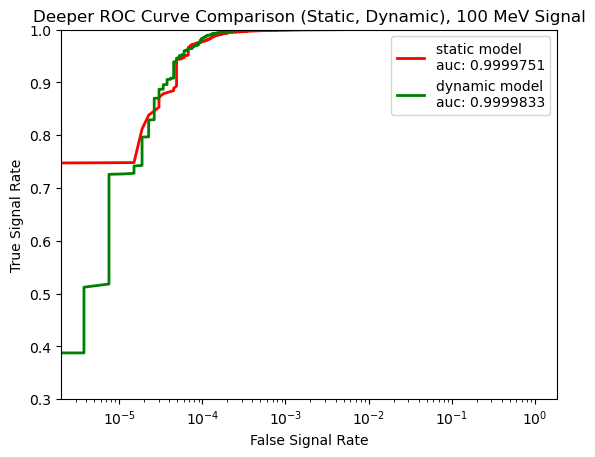

In [16]:
scores_dynamic = inference_file['y_scores_m100_dynamic']
scores_static = inference_file['y_scores_m100_static']
truths = inference_file['y_true_m100']
data_array = np.column_stack((scores_dynamic,scores_static,truths))

fpr100_s, tpr100_s, thresholds100_s = roc_curve(truths, scores_static)
roc_auc_100_s = auc(fpr100_s, tpr100_s)

fpr100_d, tpr100_d, thresholds100_d = roc_curve(truths, scores_dynamic)
roc_auc_100_d = auc(fpr100_d, tpr100_d)

plt.plot(fpr100_s, tpr100_s, label = f'static model\nauc: {roc_auc_100_s:.7f}', lw = 2, color = 'red')
plt.plot(fpr100_d, tpr100_d, label = f'dynamic model\nauc: {roc_auc_100_d:.7f}', lw = 2, color = 'green')
plt.xscale('log')
plt.ylim(0.3,1)
plt.xlabel('False Signal Rate')
plt.ylabel('True Signal Rate')
plt.title('Deeper ROC Curve Comparison (Static, Dynamic), 100 MeV Signal')
plt.legend()
print(len(truths))

In [23]:
np.max(bkgd_scores[:,0])

np.float64(0.9999985694885254)

In [24]:
threshold = 0.999999
remaining_background_dynamic = len(bkgd_scores[ bkgd_scores[:,0] > threshold])
remaining_background_static = len(bkgd_scores[ bkgd_scores[:,1] > threshold])
signal_efficiency_dynamic = len(signal_scores[ signal_scores[:,0] > threshold]) / len(signal_scores[:,0])
signal_efficiency_static = len(signal_scores[ signal_scores[:,1] > threshold]) / len(signal_scores[:,0])

In [25]:
print(f"Threshold {threshold}")
print("Dynamic")
print(f"Remaining background events {remaining_background_dynamic}, with signal efficiency {signal_efficiency_dynamic}")

print("Static")
print(f"Remaining background events {remaining_background_static}, with signal efficiency {signal_efficiency_static}")

Threshold 0.999999
Dynamic
Remaining background events 0, with signal efficiency 0.3320442582447094
Static
Remaining background events 12, with signal efficiency 0.8887456583234863


In [7]:
bkgd_scores[ bkgd_scores[:,0] > threshold]

array([[0.99999642, 1.        , 0.        ],
       [0.99999857, 0.99999964, 0.        ]])

(0.9, 1.05)

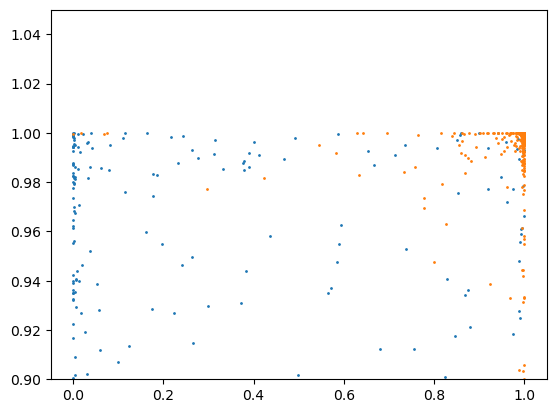

In [20]:
plt.scatter(bkgd_scores[:,0], bkgd_scores[:,1], s = 1)
plt.scatter(signal_scores[:,0], signal_scores[:,1], s = 1)
plt.ylim(0.9,1.05)

(array([[2.39003366e+05, 2.57368399e+03, 1.52406524e+03, ...,
         4.70681051e+00, 9.41362102e-01, 8.47225892e+00],
        [2.07099663e+01, 1.69445178e+01, 9.41362102e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [9.41362102e+00, 9.41362102e-01, 9.41362102e+00, ...,
         9.41362102e-01, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 1.88272420e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         9.41362102e-01, 0.00000000e+00, 9.41362102e-01],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         9.41362102e-01, 0.00000000e+00, 2.16513284e+01]], shape=(500, 500)),
 array([1.63405414e-41, 1.99999714e-03, 3.99999428e-03, 5.99999142e-03,
        7.99998856e-03, 9.99998569e-03, 1.19999828e-02, 1.39999800e-02,
        1.59999771e-02, 1.79999743e-02, 1.99999714e-02, 2.19999685e-02,
        2.39999657e-02, 2.59999

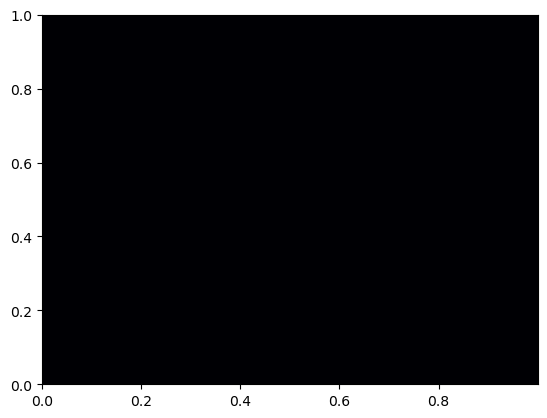